# Fase 2: Determinación de K y Clustering

**Project Terra** — Selección del número óptimo de clústeres (K) y segmentación de las zonas de muestreo mediante K-Means y Clustering Jerárquico Aglomerativo.

En este notebook partimos del dataset preprocesado y escalado (`02_preprocessing_pca.ipynb`) para:
- Determinar el K óptimo con el Método del Codo, el Coeficiente de Silueta y el Índice de Davies-Bouldin.
- Ejecutar K-Means y Clustering Jerárquico Aglomerativo con el K seleccionado.
- Comparar la coherencia entre ambos métodos.
- Exportar el dataset enriquecido con la etiqueta de clúster.

> Requiere que `02_preprocessing_pca.ipynb` se haya ejecutado previamente para generar `data/processed/sensor_Crop_Dataset_scaled.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carga de Datos Preprocesados

In [2]:
processed_path = "../data/processed/sensor_Crop_Dataset_scaled.csv"
df_scaled = pd.read_csv(processed_path)
print(f"Dimensiones: {df_scaled.shape}")
df_scaled.head()

Dimensiones: (20000, 8)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,-0.194526,0.263243,1.267102,-1.014884,0.398209,-1.613560,0.835917,Wheat
1,0.719418,0.920005,-0.888844,-0.556909,1.706133,-1.500767,-1.061136,Tomato
2,1.276206,0.802154,-1.034668,0.582042,0.822224,0.060466,-1.162575,Sugarcane
3,-1.482386,1.627335,-1.572150,-1.301155,-0.278378,-0.172904,-1.636999,Sugarcane
4,-1.322013,1.699590,-0.628804,-1.063698,-0.678517,1.533371,0.766203,Maize


In [3]:
# Separamos las variables numéricas (features) de la etiqueta de validación
target = 'Crop'

feature_cols = df_scaled.select_dtypes(include=np.number).columns.tolist()
X = df_scaled[feature_cols]

print(f"Variables usadas para clustering: {feature_cols}")

Variables usadas para clustering: ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']


## 2. Método del Codo (Elbow Method)
Evaluamos la inercia (suma de distancias al cuadrado dentro de cada clúster) para un rango de valores de K.

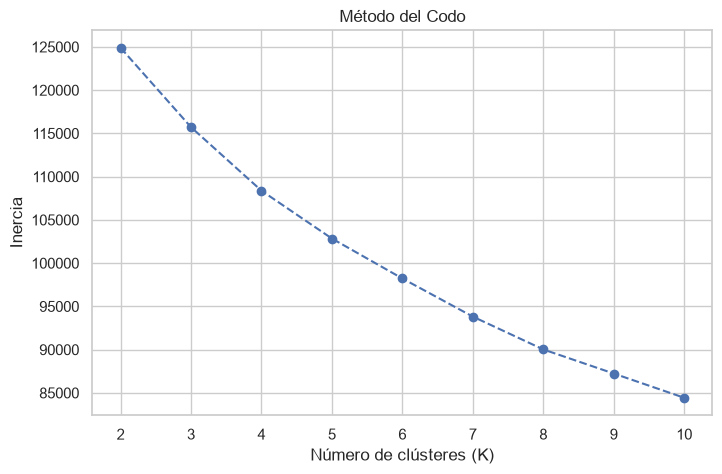

In [4]:
k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## 3. Coeficiente de Silueta
Mide qué tan bien separado y compacto está cada clúster (rango -1 a 1; valores más altos son mejores).

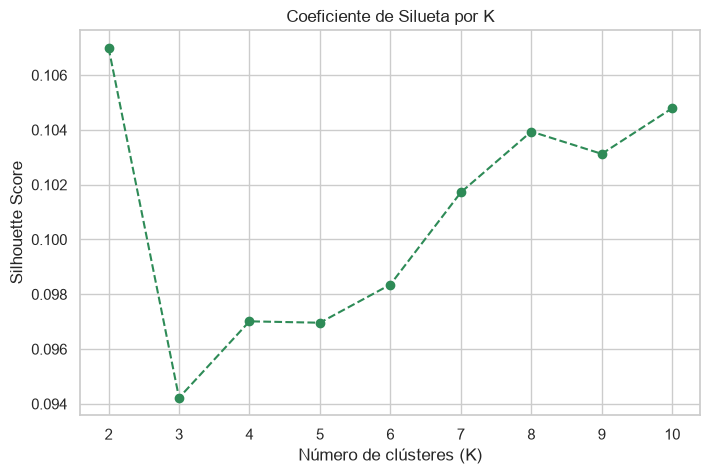

In [5]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', linestyle='--', color='seagreen')
plt.title('Coeficiente de Silueta por K')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## 4. Índice de Davies-Bouldin
Mide la similitud promedio entre cada clúster y su clúster más parecido (valores más bajos son mejores).

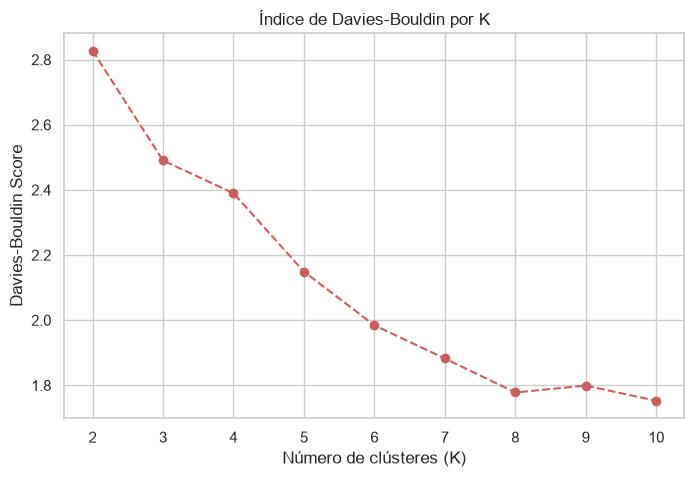

In [6]:
db_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    db_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), db_scores, marker='o', linestyle='--', color='indianred')
plt.title('Índice de Davies-Bouldin por K')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## 5. Comparación de Métricas y Selección de K

In [7]:
metrics_df = pd.DataFrame({
    'K': list(k_range),
    'Inercia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': db_scores
})
metrics_df

,K,Inercia,Silhouette,Davies-Bouldin
0,2,124895.462512,0.106998,2.827068
1,3,115714.942484,0.094222,2.490192
2,4,108372.864868,0.097013,2.389747
3,5,102840.399765,0.096962,2.149006
4,6,98222.958366,0.098355,1.984155
5,7,93815.230212,0.101720,1.882414
6,8,90020.902265,0.103941,1.777932
7,9,87235.825302,0.103125,1.799066
8,10,84434.704991,0.104791,1.752487


In [8]:
# K óptimo: ajustar este valor según el codo, el máximo de silueta y el mínimo de Davies-Bouldin observados arriba
K_OPTIMO = 4
print(f"K seleccionado: {K_OPTIMO}")

K seleccionado: 4


## 6. Clustering Jerárquico — Dendrograma
Usamos una muestra del dataset para que el dendrograma sea legible y computacionalmente manejable.

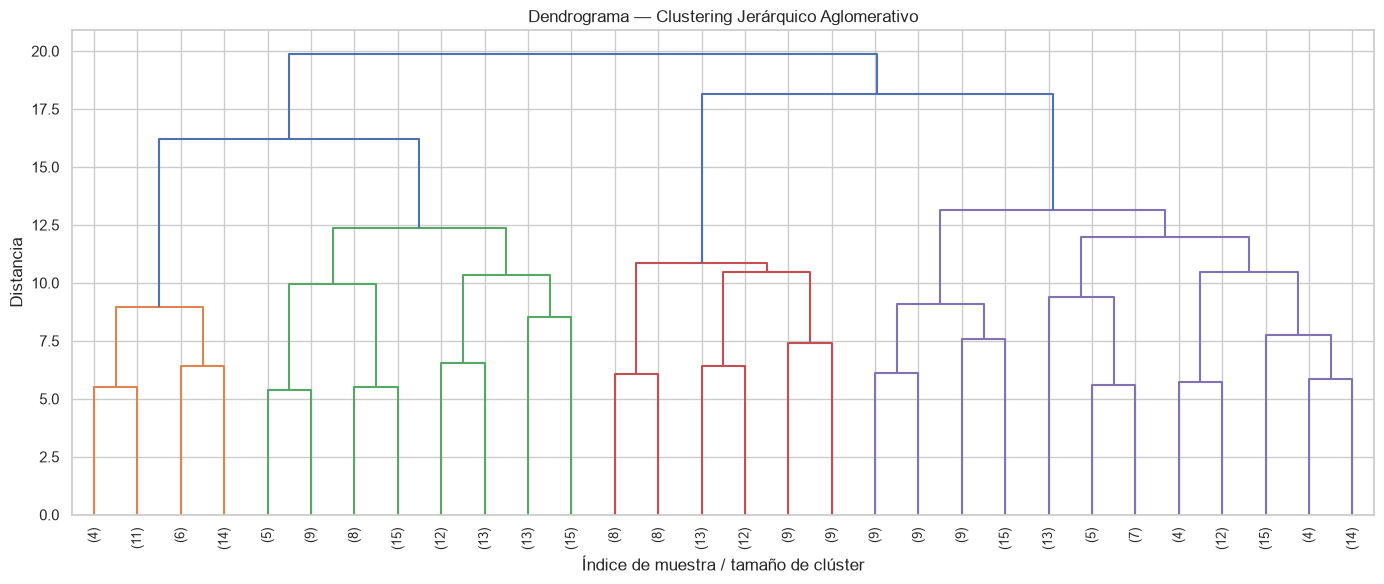

In [9]:
sample_idx = X.sample(min(300, len(X)), random_state=42).index
X_sample = X.loc[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9)
plt.title('Dendrograma — Clustering Jerárquico Aglomerativo')
plt.xlabel('Índice de muestra / tamaño de clúster')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

## 7. Ejecución de K-Means con K óptimo

In [10]:
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_scaled['cluster_kmeans'] = kmeans_final.fit_predict(X)

df_scaled['cluster_kmeans'].value_counts().sort_index()

cluster_kmeans
0    4947
1    5020
2    4964
3    5069
Name: count, dtype: int64

## 8. Ejecución de Clustering Jerárquico Aglomerativo

In [11]:
hierarchical_final = AgglomerativeClustering(n_clusters=K_OPTIMO, linkage='ward')
df_scaled['cluster_hierarchical'] = hierarchical_final.fit_predict(X)

df_scaled['cluster_hierarchical'].value_counts().sort_index()

cluster_hierarchical
0    6969
1    5392
2    5056
3    2583
Name: count, dtype: int64

## 9. Comparación entre Métodos
Usamos el Adjusted Rand Index (ARI) para medir el acuerdo entre las particiones generadas por K-Means y por el clustering jerárquico.

In [12]:
ari = adjusted_rand_score(df_scaled['cluster_kmeans'], df_scaled['cluster_hierarchical'])
print(f"Adjusted Rand Index (K-Means vs. Jerárquico): {ari:.3f}")

pd.crosstab(df_scaled['cluster_kmeans'], df_scaled['cluster_hierarchical'], rownames=['K-Means'], colnames=['Jerárquico'])

Adjusted Rand Index (K-Means vs. Jerárquico): 0.004


Jerárquico,0,1,2,3
K-Means,,,,
0,1788,1180,1134,845
1,1676,1700,1197,447
2,1728,1350,1380,506
3,1777,1162,1345,785


## 10. Exportar Dataset con Clústeres Asignados

In [13]:
clustered_path = "../data/processed/sensor_Crop_Dataset_clustered.csv"
df_scaled.to_csv(clustered_path, index=False)
print(f"Dataset guardado exitosamente en {clustered_path}")

Dataset guardado exitosamente en ../data/processed/sensor_Crop_Dataset_clustered.csv


## 11. Conclusiones preliminares

- **Método del codo**: la inercia decae de forma suave y continua (124,895 en K=2 hasta 84,435 en K=10), sin un quiebre ('codo') claro en ningún punto del rango evaluado.
- **Silueta**: valores muy bajos en todo el rango (0.09–0.11), lejos del ~0.5 que indicaría clústeres bien separados; el máximo (0.107) ocurre en K=2, no en un K mayor.
- **Davies-Bouldin**: decrece de forma monótona con K (2.83 en K=2 hasta 1.75 en K=10) sin mínimo local, lo que refuerza la ausencia de una estructura de clúster 'natural' bien definida.
- **K óptimo**: se fijó `K_OPTIMO = 4` como compromiso entre interpretabilidad (acorde al objetivo de encontrar un número reducido de 'ecorregiones') y el hecho de que ninguna métrica señala un K claramente superior a los demás.
- **Tamaño de clústeres**: muy balanceado con K-Means (entre 4,947 y 5,069 registros por clúster), pero desbalanceado con el jerárquico (entre 2,583 y 6,969).
- **Acuerdo entre métodos**: Adjusted Rand Index = **0.004** (prácticamente nulo) entre K-Means y el clustering jerárquico con K=4 — ambos métodos particionan el espacio de forma muy distinta, otra señal de que no hay una estructura de clúster fuerte y objetiva en los datos.
- **Siguiente paso**: usar `sensor_Crop_Dataset_clustered.csv` (etiquetado con `cluster_kmeans`) en `04_cluster_profiling.ipynb` para caracterizar el perfil ambiental de cada clúster y validarlo contra el cultivo real (`Crop`).